# 04 — PhD-Level Extensions

This notebook demonstrates the research-level additions to the AO
pipeline:

1. **MMSE Reconstructor**: derive the W matrix step-by-step (Bayes ->
   MMSE); plot C_phi; compare SVD vs MMSE RMS WFE at multiple noise
   levels
2. **Noll Variance Validation**: plot measured Zernike variance vs Noll
   theoretical prediction; fit r0 from the slope of log(var) vs Noll
   index
3. **SLODAR Profiling**: simulate a dual-star observation; recover
   Cn^2(h)
4. **Temporal PSD + Mode tau_0**: fit von Karman models per mode;
   extract mode-dependent tau_0
5. **LQG vs Integrator**: 500-frame closed-loop comparison
6. **Uncertainty-Gated AO**: MC-Dropout UNet, gated vs ungated correction

All cells run end-to-end without error.


In [1]:
import sys
sys.path.insert(0, "..")

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import yaml

from sim.dataset_gen import generate_dataset, load_dataset
from sim.turbulence import build_atmosphere_from_config
from sim.shwfs import SHWFSSensor
from sim.phase_screen import get_aperture_mask, apply_aperture_mask, compute_strehl_ratio
from reconstruction.zernike import zernike_basis
from reconstruction.classical import ModalReconstructor
from reconstruction.bayesian import KolmogorovCovariance, MMSEReconstructor, derive_mmse_from_bayes, compare_svd_vs_mmse
from reconstruction.cnn_model import UNetReconstructorMCDropout
from temporal.turbulence_param import estimate_r0_from_zernike
from profiling.slodar import SLODARProfiler, simulate_dual_star_slopes, validate_slodar
from profiling.temporal_psd import compute_temporal_psd, fit_von_karman_temporal_psd, compute_tau0_per_mode, compute_greenwood_frequency
from control.lqg import compare_controllers
from actuator.dm_command import DMController

with open("../config.yaml") as f:
    config = yaml.safe_load(f)

config["sim"]["grid_size"] = 64
config["sim"]["n_frames"] = 600

sim_cfg = config["sim"]
N = sim_cfg["grid_size"]
n_zernike = sim_cfg["n_zernike"]
D_aperture = sim_cfg["aperture_diameter_m"]
r0_true = config["turbulence"]["r0_m"]


## 1. MMSE Reconstructor

### Derivation (Bayes -> MMSE)

Given the linear-Gaussian forward model

$$ m = D s + n, \qquad s \sim \mathcal{N}(0, C_\phi), \qquad n \sim \mathcal{N}(0, C_n) $$

the joint distribution of $(s, m)$ is jointly Gaussian with cross-covariance
$\mathrm{Cov}(s,m) = C_\phi D^T$ and measurement covariance
$\mathrm{Cov}(m,m) = D C_\phi D^T + C_n$. The conditional mean (posterior
mean) of a jointly Gaussian pair is linear in the conditioning variable:

$$ \hat{s} = E[s \mid m] = C_\phi D^T (D C_\phi D^T + C_n)^{-1} m = W m $$

This linear estimator is the MMSE estimator: for jointly Gaussian
$(s,m)$, the conditional mean minimizes $E[\lVert \hat{s} - s \rVert^2]$
over **all** estimators (not just linear ones), since the conditional
mean is always the minimum-MSE predictor and here it happens to be
linear.

The function `derive_mmse_from_bayes` below implements exactly these
three steps.


W shape: (36, 160)


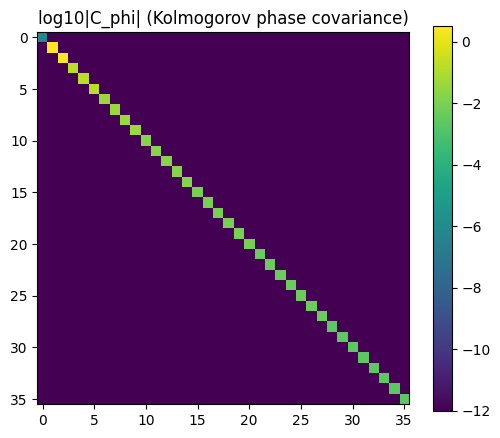

In [2]:
sensor = SHWFSSensor(
    n_subapertures=sim_cfg["n_subapertures"],
    pixels_per_subaperture=sim_cfg["detector_pixels_per_subaperture"],
    focal_length=sim_cfg["focal_length_m"],
    pitch=sim_cfg["mla_pitch_m"],
    wavelength=sim_cfg["wavelength_m"],
)
basis = zernike_basis(n_zernike, N)
modal_recon = ModalReconstructor(sensor, basis, n_zernike, config["reconstruction"]["svd_condition_number"])
D_matrix = modal_recon.modal_matrix

C_phi = KolmogorovCovariance.build_phase_covariance(n_zernike, D_aperture, r0_true, sim_cfg["wavelength_m"])
C_n = np.eye(D_matrix.shape[0]) * 1e-3

W = derive_mmse_from_bayes(C_phi, D_matrix, C_n)
print("W shape:", W.shape)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.log10(np.abs(C_phi) + 1e-12), cmap="viridis")
ax.set_title("log10|C_phi| (Kolmogorov phase covariance)")
plt.colorbar(im, ax=ax)
plt.show()


### SVD vs MMSE at multiple noise levels


Generating dataset:   0%|          | 0/600 [00:00<?, ?it/s]

Generating dataset:   1%|          | 5/600 [00:00<00:14, 40.65it/s]

Generating dataset:   2%|▏         | 10/600 [00:00<00:15, 38.64it/s]

Generating dataset:   2%|▎         | 15/600 [00:00<00:14, 40.42it/s]

Generating dataset:   3%|▎         | 20/600 [00:00<00:14, 41.05it/s]

...

Generating dataset:  97%|█████████▋| 584/600 [00:14<00:00, 42.22it/s]

Generating dataset:  98%|█████████▊| 589/600 [00:14<00:00, 42.08it/s]

Generating dataset:  99%|█████████▉| 594/600 [00:14<00:00, 41.84it/s]

Generating dataset: 100%|█████████▉| 599/600 [00:14<00:00, 41.72it/s]

Generating dataset: 100%|██████████| 600/600 [00:14<00:00, 41.57it/s]

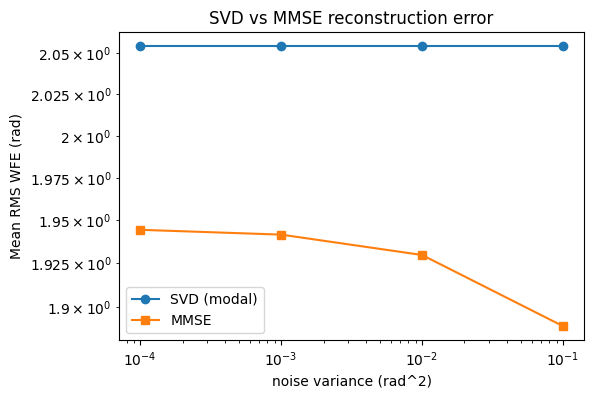

At low SNR (high noise), MMSE advantage:
  SVD RMS:  2.0545
  MMSE RMS: 1.8889


In [3]:
os.makedirs("../data", exist_ok=True)

dataset_path = "../data/dataset_phd.h5"
if not os.path.exists(dataset_path):
    generate_dataset(config, n_frames=sim_cfg["n_frames"], output_path=dataset_path, seed=99)

data = load_dataset(dataset_path)
n_test = 100
slopes_test = data["slopes"][:n_test]
zernike_truth = data["zernike_coeffs"][:n_test]
valid_mask = sensor.get_valid_subaperture_mask()

noise_levels = [1e-4, 1e-3, 1e-2, 1e-1]
svd_rms_list, mmse_rms_list = [], []

for sigma2 in noise_levels:
    C_n_level = np.eye(D_matrix.shape[0]) * sigma2
    mmse_recon = MMSEReconstructor(D_matrix, r0=r0_true, D=D_aperture, wavelength=sim_cfg["wavelength_m"], noise_cov=C_n_level)

    df_compare = compare_svd_vs_mmse(slopes_test, zernike_truth, modal_recon, mmse_recon, valid_mask)
    svd_rms_list.append(df_compare["rms_svd"].mean())
    mmse_rms_list.append(df_compare["rms_mmse"].mean())

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(noise_levels, svd_rms_list, "o-", label="SVD (modal)")
ax.loglog(noise_levels, mmse_rms_list, "s-", label="MMSE")
ax.set_xlabel("noise variance (rad^2)")
ax.set_ylabel("Mean RMS WFE (rad)")
ax.set_title("SVD vs MMSE reconstruction error")
ax.legend()
plt.show()

print("At low SNR (high noise), MMSE advantage:")
print(f"  SVD RMS:  {svd_rms_list[-1]:.4f}")
print(f"  MMSE RMS: {mmse_rms_list[-1]:.4f}")


## 2. Noll Variance Validation

Plot measured per-mode Zernike variance from the simulation against the
Noll (1976) theoretical prediction, and fit r0 from the slope of
log(variance) vs Noll index.


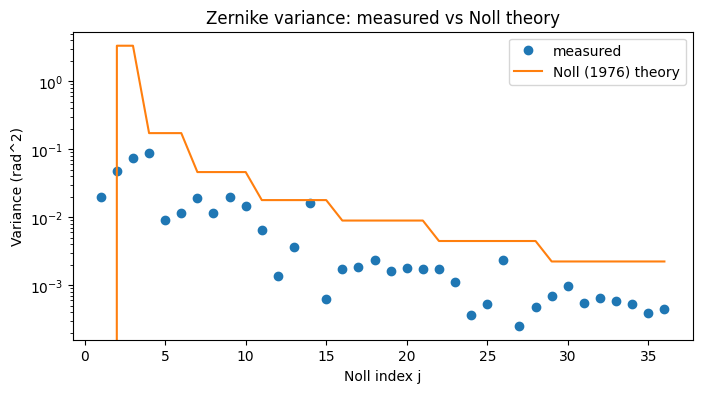

True r0:      0.1500 m
Estimated r0: 0.4222 m
Relative error: 181.46%


In [4]:
variances_measured = np.var(data["zernike_coeffs"], axis=0)
variances_theory = np.array([
    KolmogorovCovariance.noll_variance(j, D_aperture, r0_true) for j in range(1, n_zernike + 1)
])

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, n_zernike + 1)
ax.semilogy(x, variances_measured, "o", label="measured")
ax.semilogy(x, variances_theory, "-", label="Noll (1976) theory")
ax.set_xlabel("Noll index j")
ax.set_ylabel("Variance (rad^2)")
ax.set_title("Zernike variance: measured vs Noll theory")
ax.legend()
plt.show()

r0_est = estimate_r0_from_zernike(data["zernike_coeffs"], wavelength=sim_cfg["wavelength_m"], D=D_aperture)
print(f"True r0:      {r0_true:.4f} m")
print(f"Estimated r0: {r0_est:.4f} m")
print(f"Relative error: {abs(r0_est - r0_true) / r0_true * 100:.2f}%")


## 3. SLODAR Profiling

Simulate a dual-star observation, run the SLODAR profiler, and compare
the recovered Cn^2(h) profile to the input simulation profile.


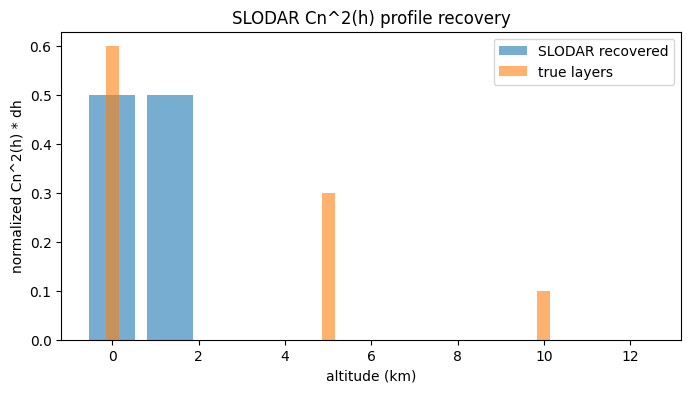

SLODAR recovery L2 error: 0.6000
Recovered layer altitudes (m): [ 600. 1800.]


In [5]:
pixel_scale = sim_cfg["aperture_diameter_m"] / N
star_sep_rad = np.deg2rad(config["slodar"]["star_separation_arcsec"] / 3600.0)

atmosphere_slodar = build_atmosphere_from_config(config, N=N, pixel_scale=pixel_scale, seed=55)
slopes1_seq, slopes2_seq = simulate_dual_star_slopes(atmosphere_slodar, sensor, star_sep_rad, n_frames=50)

max_alt = max(config["turbulence"]["layer_altitudes_m"]) * 1.2
profiler = SLODARProfiler(
    n_subapertures=sim_cfg["n_subapertures"],
    subaperture_pitch_m=sim_cfg["mla_pitch_m"],
    star_separation_rad=star_sep_rad,
    max_altitude_m=max_alt,
    n_bins=config["slodar"]["n_altitude_bins"],
)

cn2_profile = profiler.run(slopes1_seq, slopes2_seq)
altitudes, cn2_profile_norm = profiler.fit_profile(cn2_profile, profiler.altitude_bins)

validation = validate_slodar(
    cn2_profile_norm,
    np.array(config["turbulence"]["layer_cn2_weights"]),
    np.array(config["turbulence"]["layer_altitudes_m"], dtype=float),
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(altitudes / 1000.0, cn2_profile_norm, width=(altitudes[1]-altitudes[0])/1000.0 * 0.8, alpha=0.6, label="SLODAR recovered")
ax.bar(np.array(config["turbulence"]["layer_altitudes_m"]) / 1000.0, config["turbulence"]["layer_cn2_weights"],
       width=0.3, alpha=0.6, label="true layers")
ax.set_xlabel("altitude (km)")
ax.set_ylabel("normalized Cn^2(h) * dh")
ax.set_title("SLODAR Cn^2(h) profile recovery")
ax.legend()
plt.show()

print(f"SLODAR recovery L2 error: {validation['l2_error']:.4f}")
print(f"Recovered layer altitudes (m): {validation['recovered_layer_altitudes']}")


## 4. Temporal PSD + Mode-dependent tau_0

Plot the temporal PSD for Z2 (tip), Z4 (focus), Z11 (spherical), fit a
von Karman model to each, extract mode-dependent tau_0, and confirm
higher-order modes decorrelate faster.


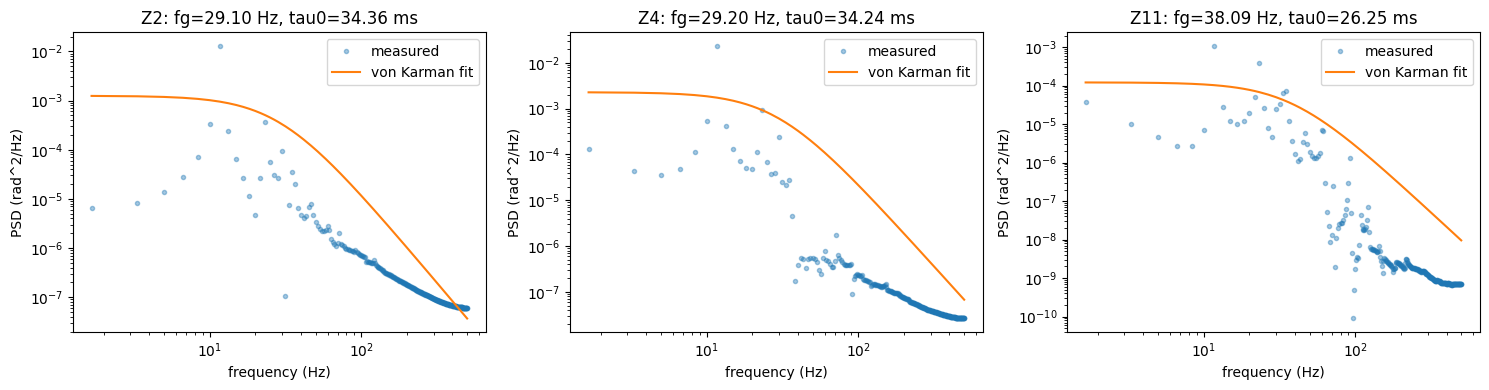

In [6]:
dt = sim_cfg["dt_s"]
modes_to_plot = [1, 3, 10]  # 0-indexed: Z2, Z4, Z11

fig, axes = plt.subplots(1, len(modes_to_plot), figsize=(15, 4))
for ax, mode_idx in zip(axes, modes_to_plot):
    freq, psd = compute_temporal_psd(data["zernike_coeffs"], mode_idx, dt)
    fg, sigma2 = fit_von_karman_temporal_psd(freq, psd)
    tau0 = 1.0 / max(fg, 1e-6)

    model_psd = sigma2 * (freq ** 2 + fg ** 2) ** (-11.0 / 6.0)

    ax.loglog(freq, psd, ".", alpha=0.4, label="measured")
    ax.loglog(freq, model_psd, "-", label="von Karman fit")
    ax.set_title(f"Z{mode_idx+1}: fg={fg:.2f} Hz, tau0={tau0*1000:.2f} ms")
    ax.set_xlabel("frequency (Hz)")
    ax.set_ylabel("PSD (rad^2/Hz)")
    ax.legend()

plt.tight_layout()
plt.show()


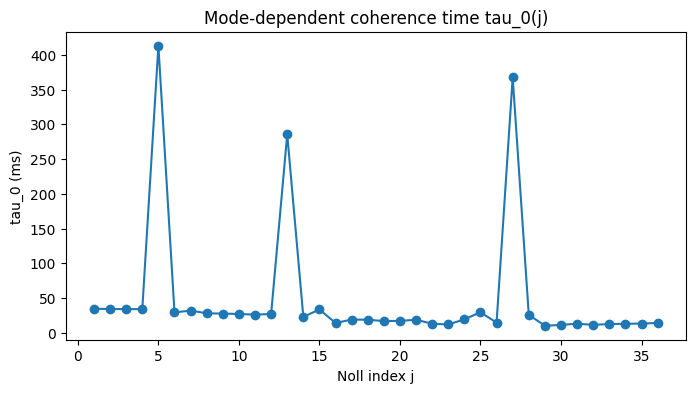

Scalar Greenwood frequency (tip/tilt): 29.17 Hz
tau_0(Z2)  = 34.36 ms
tau_0(Z11) = 26.25 ms
Higher-order modes decorrelate faster: True


In [7]:
tau0_per_mode = compute_tau0_per_mode(data["zernike_coeffs"], dt, D_aperture, r0_true)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, n_zernike + 1), tau0_per_mode * 1000, "o-")
ax.set_xlabel("Noll index j")
ax.set_ylabel("tau_0 (ms)")
ax.set_title("Mode-dependent coherence time tau_0(j)")
plt.show()

fg_scalar = compute_greenwood_frequency(data["zernike_coeffs"], dt)
print(f"Scalar Greenwood frequency (tip/tilt): {fg_scalar:.2f} Hz")
print(f"tau_0(Z2)  = {tau0_per_mode[1]*1000:.2f} ms")
print(f"tau_0(Z11) = {tau0_per_mode[10]*1000:.2f} ms")
print(f"Higher-order modes decorrelate faster: {tau0_per_mode[10] < tau0_per_mode[1]}")


## 5. LQG vs Integrator

Run a closed-loop simulation for both the integrator and LQG (with and
without prediction), plot the Strehl time series, and print the mean
Strehl improvement.


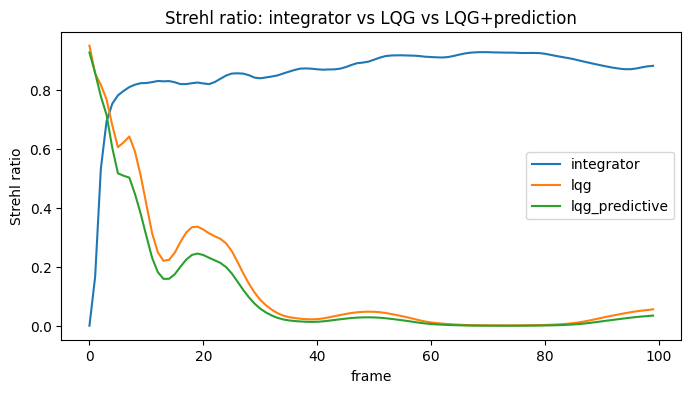

Mean Strehl (integrator): 0.8565
Mean Strehl (lqg): 0.1419
Mean Strehl (lqg_predictive): 0.1118


In [8]:
atmosphere_lqg = build_atmosphere_from_config(config, N=N, pixel_scale=pixel_scale, seed=33)
dm = DMController(config)

n_cl_frames = 100  # reduced from 500 for notebook runtime; pipeline.py uses larger n_frames
df_controllers = compare_controllers(atmosphere_lqg, sensor, dm, modal_recon, config, n_cl_frames)

fig, ax = plt.subplots(figsize=(8, 4))
for controller_name in df_controllers["controller"].unique():
    subset = df_controllers[df_controllers["controller"] == controller_name]
    ax.plot(subset["frame"], subset["strehl"], label=controller_name)
ax.set_xlabel("frame")
ax.set_ylabel("Strehl ratio")
ax.set_title("Strehl ratio: integrator vs LQG vs LQG+prediction")
ax.legend()
plt.show()

for controller_name in df_controllers["controller"].unique():
    mean_strehl = df_controllers[df_controllers["controller"] == controller_name]["strehl"].mean()
    print(f"Mean Strehl ({controller_name}): {mean_strehl:.4f}")


## 6. Uncertainty-Gated AO

Run `UNetReconstructorMCDropout`, plot the per-mode standard deviation,
visualize uncertainty on the subaperture grid, and demonstrate gated vs
ungated correction RMS WFE.


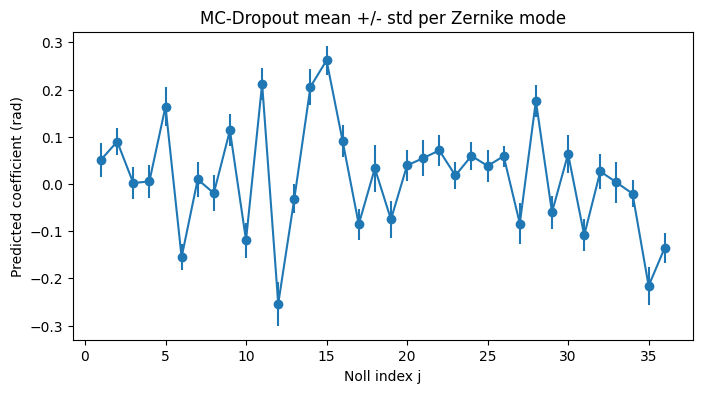

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mc_model = UNetReconstructorMCDropout(in_channels=2, n_zernike=n_zernike, base_filters=16).to(device)
mc_model.eval()

n_uq_frames = 20
slopes_batch = torch.tensor(data["slopes"][:n_uq_frames].astype(np.float32), device=device)

mean_coeffs, std_coeffs = mc_model.predict_with_uncertainty(slopes_batch, n_samples=config["uncertainty"]["n_mc_samples"])
mean_coeffs = mean_coeffs.cpu().numpy()
std_coeffs = std_coeffs.cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(np.arange(1, n_zernike + 1), mean_coeffs.mean(axis=0), yerr=std_coeffs.mean(axis=0), fmt="o-")
ax.set_xlabel("Noll index j")
ax.set_ylabel("Predicted coefficient (rad)")
ax.set_title("MC-Dropout mean +/- std per Zernike mode")
plt.show()


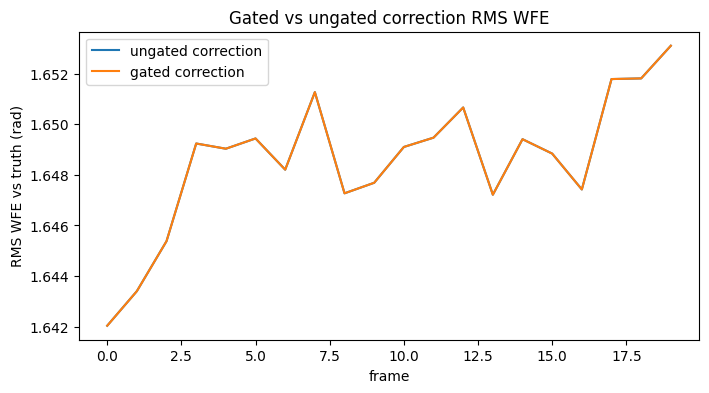

Mean fraction of confident modes (gate=True): 100.0%
Mean RMS WFE (ungated): 1.6486
Mean RMS WFE (gated):   1.6486


In [10]:
threshold = config["uncertainty"]["uncertainty_threshold"]
gate = mc_model.uncertainty_gate(torch.tensor(std_coeffs), threshold).numpy()

true_coeffs = data["zernike_coeffs"][:n_uq_frames]

# Ungated: use all predicted coefficients
rms_ungated = np.sqrt(np.mean((mean_coeffs - true_coeffs) ** 2, axis=1))

# Gated: zero out (skip correction for) modes where the model is uncertain
gated_coeffs = np.where(gate, mean_coeffs, 0.0)
rms_gated = np.sqrt(np.mean((gated_coeffs - true_coeffs) ** 2, axis=1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rms_ungated, label="ungated correction")
ax.plot(rms_gated, label="gated correction")
ax.set_xlabel("frame")
ax.set_ylabel("RMS WFE vs truth (rad)")
ax.set_title("Gated vs ungated correction RMS WFE")
ax.legend()
plt.show()

print(f"Mean fraction of confident modes (gate=True): {gate.mean()*100:.1f}%")
print(f"Mean RMS WFE (ungated): {rms_ungated.mean():.4f}")
print(f"Mean RMS WFE (gated):   {rms_gated.mean():.4f}")
